In [20]:
import importlib
import torch
from torch import nn
from tensordict.nn import TensorDictModule
from torchrl.modules import ProbabilisticActor, MaskedCategorical
from torchrl.envs.utils import ExplorationType, set_exploration_type
from collections import defaultdict

import env as env_module

importlib.reload(env_module)

<module 'env' from '/Users/tanou/IEP/Zappy/zappia/env.py'>

In [ ]:
num_cells = 256
obs_size = env_module.OBSERVATION_SIZE
n_actions = len(env_module.COMMANDS)

device = torch.device("cpu")

actor_net = nn.Sequential(
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(num_cells, device=device),
    nn.Tanh(),
    nn.LazyLinear(n_actions, device=device),
)

policy_module = TensorDictModule(
    actor_net, in_keys=["observation"], out_keys=["logits"]
)

dummy_obs = torch.zeros(1, obs_size)
policy_module(
    dummy_obs.unsqueeze(0)
    if False
    else __import__("tensordict").TensorDict({"observation": dummy_obs}, batch_size=[1])
)

policy_module = ProbabilisticActor(
    module=policy_module,
    in_keys={"logits": "logits", "mask": "action_mask"},
    out_keys=["action"],
    distribution_class=MaskedCategorical,
    return_log_prob=False,
)

policy_module.load_state_dict(torch.load("ppo_policy.pth", map_location=device, weights_only=True))
policy_module.eval()
print(
    "Poids chargés :", sum(p.numel() for p in policy_module.parameters()), "paramètres"
)

In [22]:
raw_env = env_module.ZappyEnv(host="localhost", port=4242, team="team1", freq=10000)
print("Env créé, OBSERVATION_SIZE =", obs_size)

Env créé, OBSERVATION_SIZE = 746


In [23]:
MAX_STEPS = 5000

stats = defaultdict(int)
rewards = []
actions_log = []
food_log = []

td = raw_env.reset()

with set_exploration_type(ExplorationType.DETERMINISTIC), torch.no_grad():
    for step in range(MAX_STEPS):
        td_in = td.unsqueeze(0)
        td_in = policy_module(td_in)
        action = int(td_in["action"].squeeze())

        td_in["action"] = torch.tensor([[action]])
        td_next = raw_env.step(td_in.squeeze(0))

        cmd_name = env_module.COMMANDS[action]
        reward = float(td_next.get(("next", "reward"), torch.tensor([0.0])))
        done = bool(td_next.get(("next", "done"), torch.tensor([False])))
        food = raw_env.inventory.get("food", 0)

        stats[cmd_name] += 1
        rewards.append(reward)
        actions_log.append(cmd_name)
        food_log.append(food)

        if step % 100 == 0:
            print(
                f"Step {step:4d} | food={food:3d} | level={raw_env.level} "
                f"| last cmd={cmd_name:20s} | reward={reward:+.2f} "
                f"| avg_reward={sum(rewards) / len(rewards):+.3f}"
            )

        td = td_next["next"]

        if done:
            print(f"\n*** Agent MORT au step {step} ***")
            break

print(f"\n=== RÉSULTATS ({len(rewards)} steps) ===")
print(f"Reward moyenne  : {sum(rewards) / len(rewards):+.3f}")
print(f"Reward totale   : {sum(rewards):+.1f}")
print(f"Food min atteint: {min(food_log)}")
print("\nTop commandes :")
for cmd, count in sorted(stats.items(), key=lambda x: -x[1]):
    print(f"  {cmd:25s} {count:4d}x  ({100 * count / len(rewards):.1f}%)")

Step    0 | food=  9 | level=1 | last cmd=Inventory            | reward=+0.17 | avg_reward=+0.172
Step  100 | food=  3 | level=1 | last cmd=Take food            | reward=+10.00 | avg_reward=+1.275

*** Agent MORT au step 157 ***

=== RÉSULTATS (158 steps) ===
Reward moyenne  : +1.520
Reward totale   : +240.2
Food min atteint: 1

Top commandes :
  Inventory                   42x  (26.6%)
  Forward                     34x  (21.5%)
  Right                       28x  (17.7%)
  Take food                   26x  (16.5%)
  Left                         8x  (5.1%)
  Take sibur                   6x  (3.8%)
  Set sibur                    6x  (3.8%)
  Take linemate                2x  (1.3%)
  Set linemate                 2x  (1.3%)
  Take mendiane                2x  (1.3%)
  Set mendiane                 2x  (1.3%)


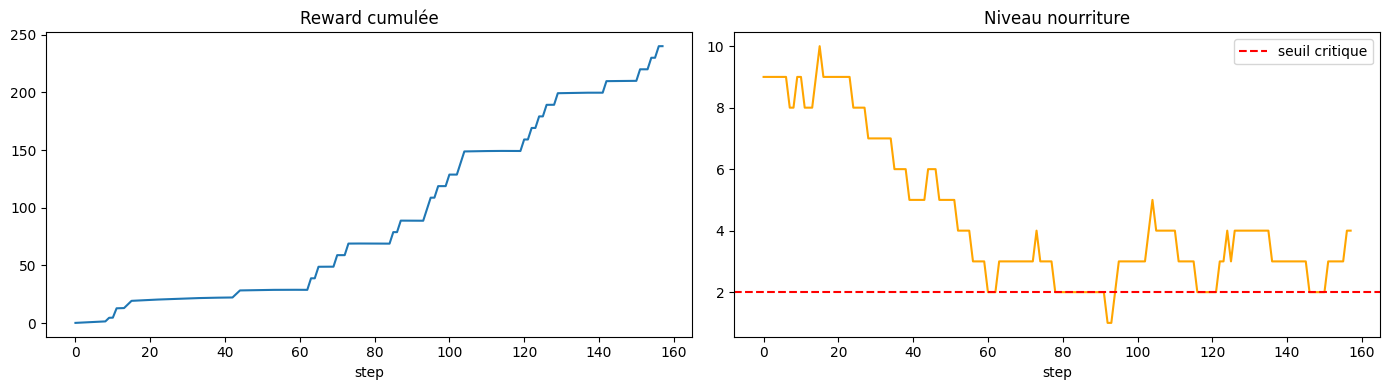

In [24]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

cumulative = [sum(rewards[: i + 1]) for i in range(len(rewards))]
ax1.plot(cumulative)
ax1.set_title("Reward cumulée")
ax1.set_xlabel("step")

ax2.plot(food_log, color="orange")
ax2.axhline(y=2, color="red", linestyle="--", label="seuil critique")
ax2.set_title("Niveau nourriture")
ax2.set_xlabel("step")
ax2.legend()

plt.tight_layout()
plt.show()